<a href="https://colab.research.google.com/github/fourmodern/molecular_docking_tutorial/blob/main/practical_docking/06_Scoring_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fourmodern/molecular_docking_tutorial/blob/main/practical_docking/06_Scoring_Validation.ipynb)

# Scoring Validation — 실험값(IC50) vs 도킹 스코어 비교

## 목적

ChEMBL에서 EGFR IC50가 알려진 화합물 30개를 수집하고, 여러 scoring function으로 도킹하여
**어떤 스코어가 실험 활성을 가장 잘 예측하는지** 검증합니다.

## 이론적 배경

### 도킹 스코어의 한계
도킹 스코어는 결합 에너지의 **근사치**이지 정확한 예측이 아닙니다.
실험값(IC50)과의 상관관계를 검증해야 스코어링 함수의 신뢰성을 알 수 있습니다.

### Scoring Functions
- **Vina (default)**: knowledge-based + empirical 하이브리드
- **Vinardo**: Vina 개선형, 더 단순한 항으로 재파라미터화
- **ad4_scoring**: AutoDock4 force field 기반

### Consensus Scoring
여러 scoring function의 결과를 조합하면 단일 함수보다 예측력이 향상될 수 있습니다.

### pIC50
IC50를 로그 스케일로 변환: pIC50 = -log10(IC50 in M)
높을수록 강한 활성. 도킹 스코어(음수, 낮을수록 강함)와 음의 상관관계 기대.

## 워크플로우
1. ChEMBL에서 EGFR IC50 화합물 30개 수집
2. EGFR 구조 준비 + Box 설정
3. 3가지 Scoring Function으로 도킹
4. Score vs pIC50 상관관계 분석
5. Consensus Scoring 모델
6. 최적 모델 선택


## 0. 환경 설정


In [1]:
#@title 환경 설치 {display-mode: "form"}
import subprocess, sys, os

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(pkgs))

pip_install('rdkit', 'openbabel-wheel', 'gemmi')
pip_install('pdbfixer', 'openmm')
pip_install('py3Dmol', 'MDAnalysis')
pip_install('seaborn', 'pandas', 'matplotlib', 'requests', 'scikit-learn')
pip_install('chembl_webresource_client')
try: pip_install('pymol-open-source')
except: pass

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
os.makedirs(BIN_DIR, exist_ok=True)
smina_path = os.path.join(BIN_DIR, 'smina')
if not os.path.exists(smina_path):
    import stat, urllib.request
    urllib.request.urlretrieve(
        'https://sourceforge.net/projects/smina/files/smina.static/download', smina_path)
    os.chmod(smina_path, os.stat(smina_path).st_mode | stat.S_IEXEC | stat.S_IXGRP | stat.S_IXOTH)
os.environ['PATH'] = BIN_DIR + ':' + os.environ['PATH']
print('Done.')


Done.


### 라이브러리 로드

도킹, 화학정보학, 통계, 머신러닝에 필요한 라이브러리를 불러옵니다.
- **chembl_webresource_client**: ChEMBL 데이터베이스 API
- **scipy.stats**: Pearson/Spearman 상관계수
- **sklearn**: Linear Regression, Random Forest


In [2]:
#@title 라이브러리 로드 {display-mode: "form"}
import warnings; warnings.filterwarnings('ignore')
import os, subprocess, urllib.request, time, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import py3Dmol
import requests
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
from openbabel import pybel
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import MDAnalysis as mda
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

BIN_DIR = '/opt/bin' if os.path.exists('/opt/bin/smina') else '/content/bin'
WORK_DIR = '/content/scoring_validation' if os.path.exists('/content') else os.path.join(os.path.expanduser('~'), 'scoring_validation')
os.makedirs(WORK_DIR, exist_ok=True)
print('All libraries loaded.')


All libraries loaded.


## 1. ChEMBL에서 EGFR IC50 화합물 수집

ChEMBL API를 사용하여 EGFR (target) 대상 IC50 활성 데이터가 있는 화합물을 수집합니다.

**설정값** (1-1. ChEMBL 검색):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `TARGET_CHEMBL_ID` | `CHEMBL203` | 문자열 | ChEMBL 타겟 ID |
| `N_COMPOUNDS` | `30` | 정수 | 수집할 화합물 수 |
| `IC50_MAX_NM` | `10000` | 숫자 | IC50 상한값 (nM) |


In [3]:
#@title 1-1. ChEMBL 검색 {display-mode: "form"}
TARGET_CHEMBL_ID = "CHEMBL203"  #@param {type:"string"}
N_COMPOUNDS = 30  #@param {type:"integer"}
IC50_MAX_NM = 10000  #@param {type:"number"}

from chembl_webresource_client.new_client import new_client

# Search for bioactivity data
activity = new_client.activity
results = activity.filter(
    target_chembl_id=TARGET_CHEMBL_ID,
    standard_type='IC50',
    standard_units='nM',
    standard_relation='=',
    assay_type='B'  # Binding assay
).only([
    'molecule_chembl_id', 'canonical_smiles', 'standard_value',
    'standard_units', 'pchembl_value'
])

# Collect and filter
compounds = []
seen_smiles = set()
for r in results:
    smi = r.get('canonical_smiles')
    ic50 = r.get('standard_value')
    pchembl = r.get('pchembl_value')
    chembl_id = r.get('molecule_chembl_id')

    if not smi or not ic50 or smi in seen_smiles:
        continue

    try:
        ic50_val = float(ic50)
        if ic50_val <= 0 or ic50_val > IC50_MAX_NM:
            continue
    except: continue

    mol = Chem.MolFromSmiles(smi)
    if mol is None: continue
    ha = mol.GetNumHeavyAtoms()
    if ha < 15 or ha > 60: continue  # reasonable drug size

    pIC50 = -math.log10(ic50_val * 1e-9) if ic50_val > 0 else None

    compounds.append({
        'ChEMBL_ID': chembl_id,
        'SMILES': smi,
        'IC50_nM': round(ic50_val, 2),
        'pIC50': round(pIC50, 2) if pIC50 else None,
        'pChEMBL': float(pchembl) if pchembl else None,
        'MW': round(Descriptors.MolWt(mol), 1),
        'HA': ha,
    })
    seen_smiles.add(smi)

    if len(compounds) >= N_COMPOUNDS * 3:  # collect extra for diversity
        break

# Pre-generate 3D SDF for each compound via openbabel (avoids atom count mismatch from RDKit roundtrip)
for cpd in compounds:
    lig_sdf = os.path.join(WORK_DIR, f'{cpd["ChEMBL_ID"]}.sdf')
    try:
        ob_mol = pybel.readstring('smi', cpd['SMILES'])
        ob_mol.addh()
        ob_mol.make3D(forcefield='mmff94', steps=100)
        lout = pybel.Outputfile(filename=lig_sdf, format='sdf', overwrite=True)
        lout.write(ob_mol); lout.close()
        cpd['sdf_path'] = lig_sdf
    except Exception as e:
        print(f'  Warning: openbabel 3D failed for {cpd["ChEMBL_ID"]}: {e}')
        cpd['sdf_path'] = None

print(f'Collected {len(compounds)} compounds from ChEMBL')


Collected 90 compounds from ChEMBL


### 활성 범위가 다양한 30개 선별

pIC50 범위를 5등분하여 각 구간에서 균등하게 선별합니다.
강한 활성(높은 pIC50)부터 약한 활성까지 고르게 포함해야 상관관계 분석이 의미있습니다.


In [4]:
#@title 1-2. 활성 범위가 다양한 30개 선별 {display-mode: "form"}
df_all = pd.DataFrame(compounds).dropna(subset=['pIC50']).sort_values('pIC50')

# Select diverse range: top/middle/bottom
n = N_COMPOUNDS
if len(df_all) >= n:
    # Stratified sampling across pIC50 range
    df_all['bin'] = pd.qcut(df_all['pIC50'], q=min(5, len(df_all)), labels=False, duplicates='drop')
    selected = df_all.groupby('bin', group_keys=False).apply(
        lambda x: x.sample(min(len(x), n // 5 + 1), random_state=42)
    ).head(n)
else:
    selected = df_all.head(n)

selected = selected.sort_values('pIC50', ascending=False).reset_index(drop=True)
selected.index += 1

print(f'Selected {len(selected)} compounds (pIC50 range: {selected["pIC50"].min():.1f} ~ {selected["pIC50"].max():.1f})')
selected[['ChEMBL_ID', 'SMILES', 'IC50_nM', 'pIC50', 'MW']]


Selected 30 compounds (pIC50 range: 5.0 ~ 8.8)


,ChEMBL_ID,SMILES,IC50_nM,pIC50,MW
1,CHEMBL138363,C=C(C)C(=O)Nc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,1.6,8.80,384.2
2,CHEMBL67003,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,1.8,8.74,560.6
3,CHEMBL305246,Cc1cc(C(=O)N2CCN(C)CC2)[nH]c1/C=C1\C(=O)Nc2ncn...,2.8,8.55,495.9
4,CHEMBL69071,Cc1cc(C(=O)N2CC(C)NC(C)C2)[nH]c1/C=C1\C(=O)Nc2...,5.9,8.23,510.0
5,CHEMBL66570,CCN1CCN(C(=O)c2cc(C)c(/C=C3\C(=O)Nc4ncnc(Nc5cc...,13.0,7.89,510.0
6,CHEMBL302552,O=C1Nc2ncnc(Nc3ccc(F)c(Cl)c3)c2/C1=C/c1ccc(C(=...,22.0,7.66,511.9
7,CHEMBL424093,Brc1cccc(Nc2ncnc3ccc(N/N=N/Cc4ccccc4)cc23)c1,25.0,7.60,433.3
8,CHEMBL111197,COc1cccc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3...,30.0,7.52,427.3
9,CHEMBL137534,CN(C)CC/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,38.0,7.42,414.3
10,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,7.39,383.8


### pIC50 분포 & 2D 구조

선별된 30개 화합물의 활성 분포와 대표 구조를 확인합니다.
pIC50가 5~10 범위에 고르게 분포하는 것이 이상적입니다.


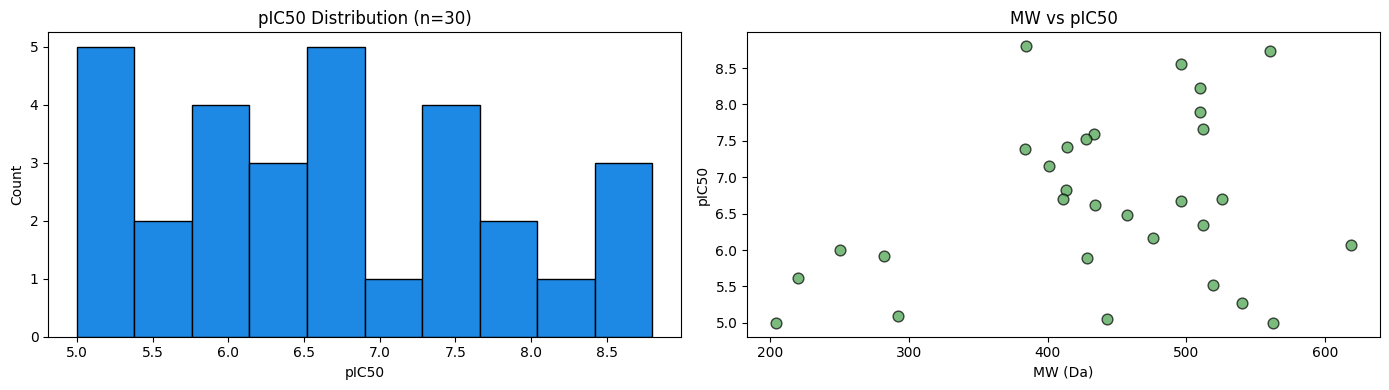

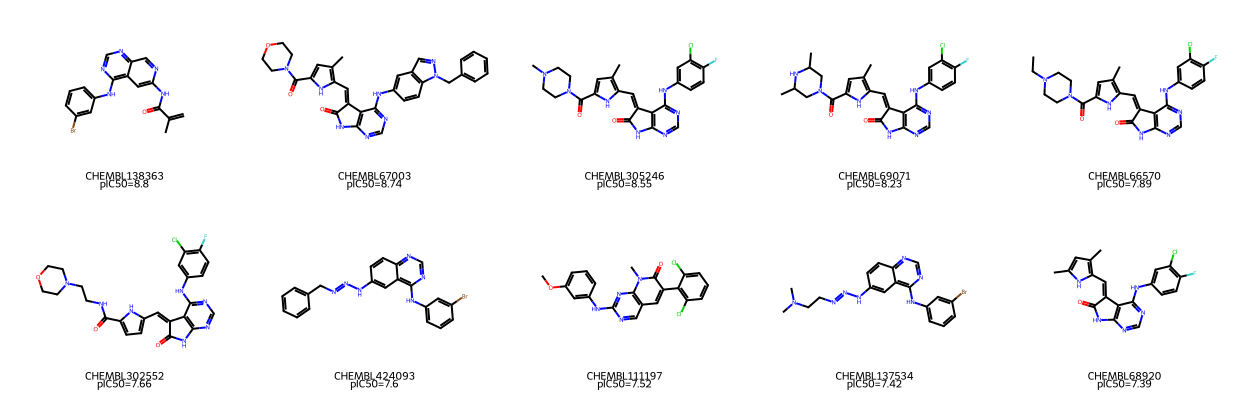

In [5]:
#@title 1-3. pIC50 분포 & 2D 구조 {display-mode: "form"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# pIC50 distribution
axes[0].hist(selected['pIC50'], bins=10, color='#1E88E5', edgecolor='black')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title(f'pIC50 Distribution (n={len(selected)})')

# MW vs pIC50
axes[1].scatter(selected['MW'], selected['pIC50'], s=60, alpha=0.7, c='#43A047', edgecolors='black')
axes[1].set_xlabel('MW (Da)')
axes[1].set_ylabel('pIC50')
axes[1].set_title('MW vs pIC50')

plt.tight_layout()
plt.show()

# 2D structures (top 10)
mols = [Chem.MolFromSmiles(s) for s in selected['SMILES'].head(10)]
legends = [f"{row['ChEMBL_ID']}\npIC50={row['pIC50']}" for _, row in selected.head(10).iterrows()]
Draw.MolsToGridImage(mols, legends=legends, molsPerRow=5, subImgSize=(250, 200))


## 2. EGFR 구조 준비

EGFR WT 구조 (1M17)를 준비하고 docking box를 설정합니다.

**설정값** (2-1. PDB 준비 + Box 설정):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `TARGET_PDB` | `1M17` | 문자열 | RCSB PDB 코드 |
| `TARGET_CHAIN` | `A` | 문자열 | 단백질 체인 ID |
| `PADDING` | `7.0` | 숫자 | 도킹 박스 여유 공간 (Å) |


In [6]:
#@title 2-1. PDB 준비 + Box 설정 {display-mode: "form"}
TARGET_PDB = "1M17"  #@param {type:"string"}
TARGET_CHAIN = "A"   #@param {type:"string"}
PADDING = 7.0        #@param {type:"number"}

os.chdir(WORK_DIR)
pdb_id = TARGET_PDB.lower()

# Fetch
pdb_path = os.path.join(WORK_DIR, f'{pdb_id}.pdb')
if not os.path.exists(pdb_path):
    urllib.request.urlretrieve(f'https://files.rcsb.org/download/{pdb_id}.pdb', pdb_path)

# Extract protein + ligand
u = mda.Universe(pdb_path)
prot_sel = u.select_atoms(f'protein and chainID {TARGET_CHAIN}')
lig_sel = u.select_atoms(f'not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI and chainID {TARGET_CHAIN}')
if len(lig_sel) < 3:
    lig_sel = u.select_atoms('not protein and not nucleic and not resname HOH WAT SOL GOL PEG EDO PG4 DMS ACT BME CL NA MG ZN CA SO4 MN FE CU CO NI CD K BR IOD PO4 NO3 SCN CIT FMT TRS MPD IPA EOH MLI AZI')

    # 여러 잔기가 있으면 가장 큰 것(약물)만 선택
    if len(lig_sel) > 0:
        resnames = list(set(lig_sel.resnames))
        if len(resnames) > 1:
            biggest = max(resnames, key=lambda r: len(lig_sel.select_atoms(f'resname {r}')))
            lig_sel = lig_sel.select_atoms(f'resname {biggest}')
            print(f'  Keeping largest ligand: {biggest} ({len(lig_sel)} atoms)')

clean_pdb = os.path.join(WORK_DIR, f'{pdb_id}_clean.pdb')
prot_sel.write(clean_pdb)

# PDBFixer
prot_H = os.path.join(WORK_DIR, f'{pdb_id}_clean_H.pdb')
fixer = PDBFixer(filename=clean_pdb)
fixer.findMissingResidues(); fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues(); fixer.removeHeterogens(True)
fixer.findMissingAtoms(); fixer.addMissingAtoms(); fixer.addMissingHydrogens(7.4)
with open(prot_H, 'w') as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f)

# Receptor PDBQT
rec_qt = os.path.join(WORK_DIR, f'{pdb_id}_rec.pdbqt')
obmol = list(pybel.readfile(format='pdb', filename=prot_H))[0]
out = pybel.Outputfile(filename=rec_qt+'.tmp', format='pdbqt', overwrite=True)
out.write(obmol); out.close()
skip_tags = ('ROOT','ENDROOT','BRANCH','ENDBRANCH','TORSDOF')
skip_kw = ('torsion','active','between atoms','status')
with open(rec_qt+'.tmp') as f: raw = f.readlines()
with open(rec_qt, 'w') as f:
    for l in raw:
        if l.startswith(skip_tags): continue
        if l.startswith('REMARK') and any(k in l.lower() for k in skip_kw): continue
        f.write(l)
os.remove(rec_qt+'.tmp')

# Box from co-crystal ligand
coords = lig_sel.positions
minC, maxC = coords.min(axis=0), coords.max(axis=0)
center = {'x': float((maxC[0]+minC[0])/2), 'y': float((maxC[1]+minC[1])/2), 'z': float((maxC[2]+minC[2])/2)}
size = {'x': float(maxC[0]-minC[0]+2*PADDING), 'y': float(maxC[1]-minC[1]+2*PADDING), 'z': float(maxC[2]-minC[2]+2*PADDING)}

print(f'Receptor: {rec_qt}')
print(f'Box center: ({center["x"]:.1f}, {center["y"]:.1f}, {center["z"]:.1f})')
print(f'Box size: ({size["x"]:.1f}, {size["y"]:.1f}, {size["z"]:.1f})')


Receptor: /content/scoring_validation/1m17_rec.pdbqt
Box center: (21.7, 0.3, 52.1)
Box size: (29.7, 18.7, 21.1)


## 3. 3가지 Scoring Function으로 도킹

smina는 `--scoring` 옵션으로 다양한 scoring function을 사용할 수 있습니다:
- **vina** (기본): Trott & Olson, 2010
- **vinardo**: Quiroga & Villarreal, 2016  
- **ad4_scoring**: Morris et al., AutoDock4 force field

**설정값** (3-1. 전체 도킹 (3 scoring functions × 30 compounds)):

| 변수 | 기본값 | 타입 | 설명 |
|------|--------|------|------|
| `EXHAUSTIVENESS` | `8` | 정수 | 도킹 탐색 깊이 (높을수록 정확, 느림) |
| `N_POSES` | `5` | 정수 | 생성할 도킹 포즈 수 |
| `N_CPUS` | `0` | 정수 | CPU 코어 수 (0=자동) |


In [7]:
#@title 3-1. 전체 도킹 (3 scoring functions × 30 compounds) {display-mode: "form"}
SCORING_FUNCTIONS = ['vina', 'vinardo', 'ad4_scoring']
EXHAUSTIVENESS = 8   #@param {type:"integer"}
N_POSES = 5          #@param {type:"integer"}
N_CPUS = 0           #@param {type:"integer"}

smina = os.path.join(BIN_DIR, 'smina')
dock_results = []
t0 = time.time()

total = len(selected) * len(SCORING_FUNCTIONS)
done = 0

for _, row in selected.iterrows():
    name = row['ChEMBL_ID']
    smi = row['SMILES']

    # Prepare ligand SDF via openbabel (avoids atom count mismatch from RDKit roundtrip)
    lig_sdf = os.path.join(WORK_DIR, f'{name}.sdf')
    try:
        ob_mol = pybel.readstring('smi', smi)
        ob_mol.addh()
        ob_mol.make3D(forcefield='mmff94', steps=100)
        lout = pybel.Outputfile(filename=lig_sdf, format='sdf', overwrite=True)
        lout.write(ob_mol); lout.close()
    except Exception as e:
        print(f'  openbabel 3D failed ({e}), using RDKit fallback')
        mol = Chem.MolFromSmiles(smi)
        if mol is None: continue
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
        writer = Chem.SDWriter(lig_sdf)
        writer.write(mol)
        writer.close()

    result_row = {
        'Name': name, 'SMILES': smi,
        'IC50_nM': row['IC50_nM'], 'pIC50': row['pIC50'],
        'MW': row['MW'], 'HA': row['HA'],
    }

    # Dock with each scoring function
    for sf in SCORING_FUNCTIONS:
        done += 1
        print(f'[{done}/{total}] {name} / {sf}...', end=' ', flush=True)

        sdf_out = os.path.join(WORK_DIR, f'{name}_{sf}_docked.sdf')

        cmd = f'{smina} -r {rec_qt} -l {lig_sdf} -o {sdf_out} --scoring {sf} --center_x {center["x"]} --center_y {center["y"]} --center_z {center["z"]} --size_x {size["x"]} --size_y {size["y"]} --size_z {size["z"]} --exhaustiveness {EXHAUSTIVENESS} --num_modes {N_POSES} --cpu {N_CPUS} 2>/dev/null'
        os.system(cmd)

        # Parse all poses
        scores = []
        if os.path.exists(sdf_out) and os.path.getsize(sdf_out) > 0:
            suppl = list(Chem.SDMolSupplier(sdf_out, removeHs=False))
            for pose_mol in suppl:
                if pose_mol is None: continue
                p = pose_mol.GetPropsAsDict()
                if 'minimizedAffinity' in p:
                    try: scores.append(float(p['minimizedAffinity']))
                    except: pass

        result_row[f'{sf}_best'] = min(scores) if scores else None
        result_row[f'{sf}_mean'] = round(np.mean(scores), 2) if scores else None
        result_row[f'{sf}_n_poses'] = len(scores)

        print(f'{min(scores):.2f}' if scores else 'FAILED')

    dock_results.append(result_row)

elapsed = time.time() - t0
print(f'\n=== {len(dock_results)} compounds × {len(SCORING_FUNCTIONS)} SFs in {elapsed:.0f}s ===')


[1/90] CHEMBL138363 / vina... -8.60
[2/90] CHEMBL138363 / vinardo... 

[04:18:09] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:09] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:09] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:09] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:09] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-7.96
[3/90] CHEMBL138363 / ad4_scoring... 

[04:18:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[04:18:47] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-40.83
[4/90] CHEMBL67003 / vina... 

...

[06:50:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:17] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-5.96
[90/90] CHEMBL296407 / ad4_scoring... 

[06:50:32] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:32] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:32] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:32] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:32] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


-28.49

=== 30 compounds × 3 SFs in 9204s ===


[06:50:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:50:58] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


## 4. Score vs pIC50 상관관계 분석

각 scoring function의 도킹 스코어가 실험값(pIC50)과 얼마나 상관관계가 있는지 평가합니다.
- **Pearson R**: 선형 상관관계 (-1 ~ 1)
- **Spearman ρ**: 순위 상관관계
- 도킹 스코어는 음수(낮을수록 강함), pIC50는 양수(높을수록 강함)이므로 **음의 상관관계**가 기대됩니다.


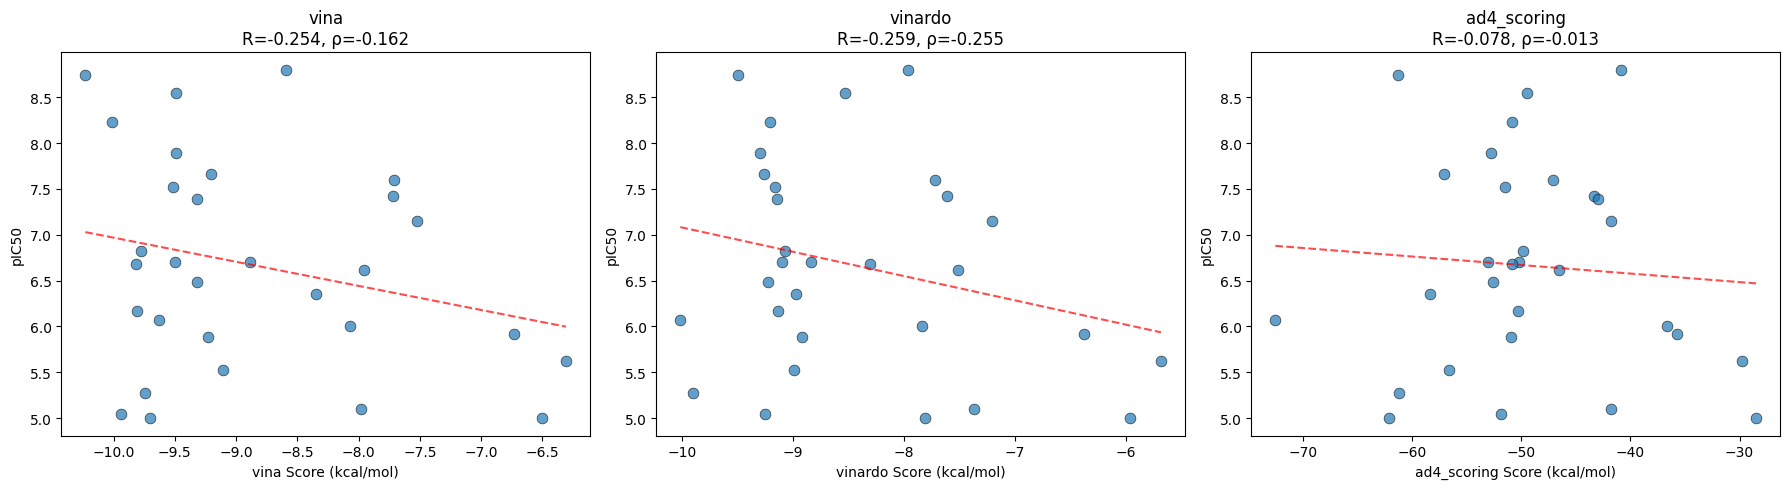

=== Scoring Function 비교 ===


,Scoring Function,Pearson R,Pearson p,Spearman ρ,Spearman p,N
0,vina,-0.254,1.76e-01,-0.162,3.92e-01,30
1,vinardo,-0.259,1.66e-01,-0.255,1.74e-01,30
2,ad4_scoring,-0.078,6.80e-01,-0.013,9.46e-01,30


In [8]:
#@title 4-1. 상관관계 테이블 & 산점도 {display-mode: "form"}
df = pd.DataFrame(dock_results).dropna(subset=['pIC50'])

fig, axes = plt.subplots(1, len(SCORING_FUNCTIONS), figsize=(6*len(SCORING_FUNCTIONS), 5))
if len(SCORING_FUNCTIONS) == 1: axes = [axes]

correlation_results = []

for idx, sf in enumerate(SCORING_FUNCTIONS):
    col = f'{sf}_best'
    valid = df.dropna(subset=[col])

    if len(valid) < 3:
        print(f'{sf}: not enough data')
        continue

    x = valid[col].values
    y = valid['pIC50'].values

    # Correlations
    pearson_r, pearson_p = stats.pearsonr(x, y)
    spearman_r, spearman_p = stats.spearmanr(x, y)

    correlation_results.append({
        'Scoring Function': sf,
        'Pearson R': round(pearson_r, 3),
        'Pearson p': f'{pearson_p:.2e}',
        'Spearman ρ': round(spearman_r, 3),
        'Spearman p': f'{spearman_p:.2e}',
        'N': len(valid),
    })

    # Scatter plot
    axes[idx].scatter(x, y, s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

    # Trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r--', alpha=0.7)

    axes[idx].set_xlabel(f'{sf} Score (kcal/mol)')
    axes[idx].set_ylabel('pIC50')
    axes[idx].set_title(f'{sf}\nR={pearson_r:.3f}, ρ={spearman_r:.3f}')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'score_vs_pic50.png'), dpi=150, bbox_inches='tight')
plt.show()

corr_df = pd.DataFrame(correlation_results)
print('=== Scoring Function 비교 ===')
corr_df


### Score vs pIC50 상관관계

각 scoring function의 도킹 스코어가 실험 활성(pIC50)과 얼마나 상관관계가 있는지 평가합니다.

- **Pearson R**: 선형 상관관계 (값의 크기)
- **Spearman ρ**: 순위 상관관계 (순위의 일치도)
- 도킹 스코어(음수)와 pIC50(양수)는 **음의 상관관계**가 기대됩니다.


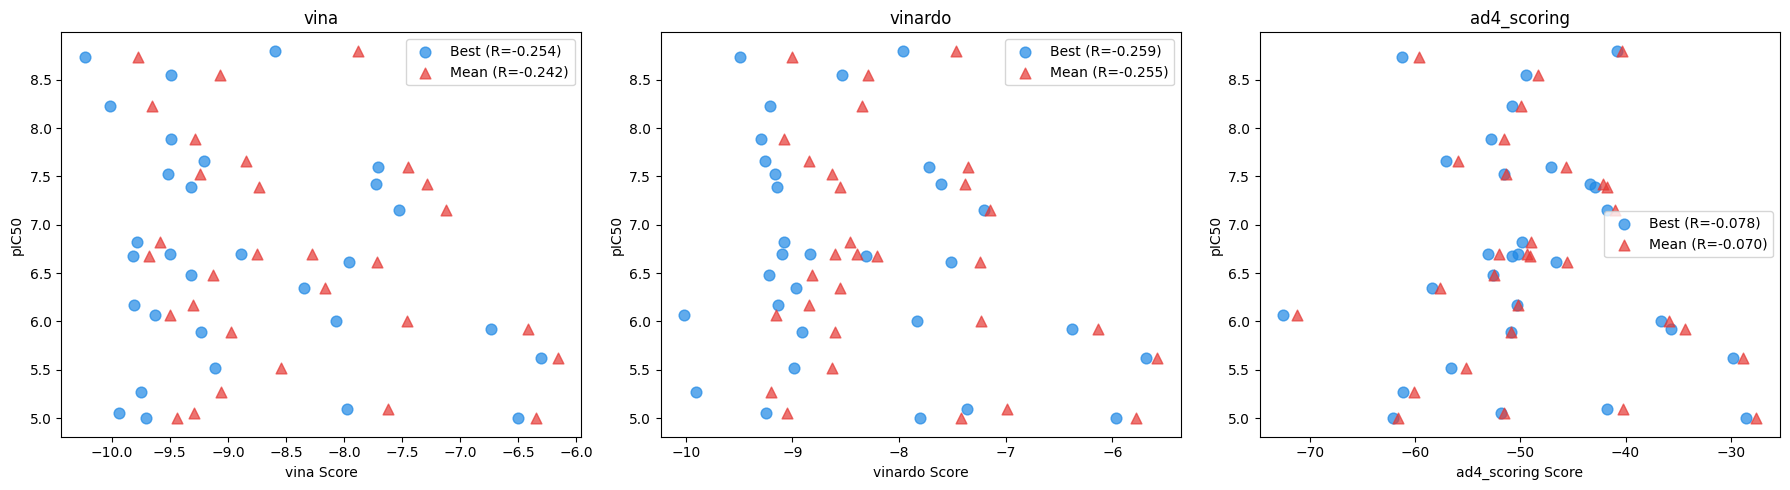

In [9]:
#@title 4-2. Best vs Mean 스코어 비교 {display-mode: "form"}
fig, axes = plt.subplots(1, len(SCORING_FUNCTIONS), figsize=(6*len(SCORING_FUNCTIONS), 5))
if len(SCORING_FUNCTIONS) == 1: axes = [axes]

for idx, sf in enumerate(SCORING_FUNCTIONS):
    best_col = f'{sf}_best'
    mean_col = f'{sf}_mean'
    valid = df.dropna(subset=[best_col, mean_col])

    if len(valid) < 3: continue

    r_best, _ = stats.pearsonr(valid[best_col], valid['pIC50'])
    r_mean, _ = stats.pearsonr(valid[mean_col], valid['pIC50'])

    axes[idx].scatter(valid[best_col], valid['pIC50'], s=60, alpha=0.7, label=f'Best (R={r_best:.3f})', c='#1E88E5')
    axes[idx].scatter(valid[mean_col], valid['pIC50'], s=60, alpha=0.7, label=f'Mean (R={r_mean:.3f})', c='#E53935', marker='^')
    axes[idx].set_xlabel(f'{sf} Score')
    axes[idx].set_ylabel('pIC50')
    axes[idx].set_title(sf)
    axes[idx].legend()

plt.tight_layout()
plt.show()


### Scoring Function 간 상관관계

서로 다른 scoring function이 같은 순위를 매기는지 확인합니다.
- 상관관계가 높으면: SF들이 비슷한 결과 → consensus 효과 제한적
- 상관관계가 낮으면: SF들이 다른 관점 → consensus가 유의미하게 향상


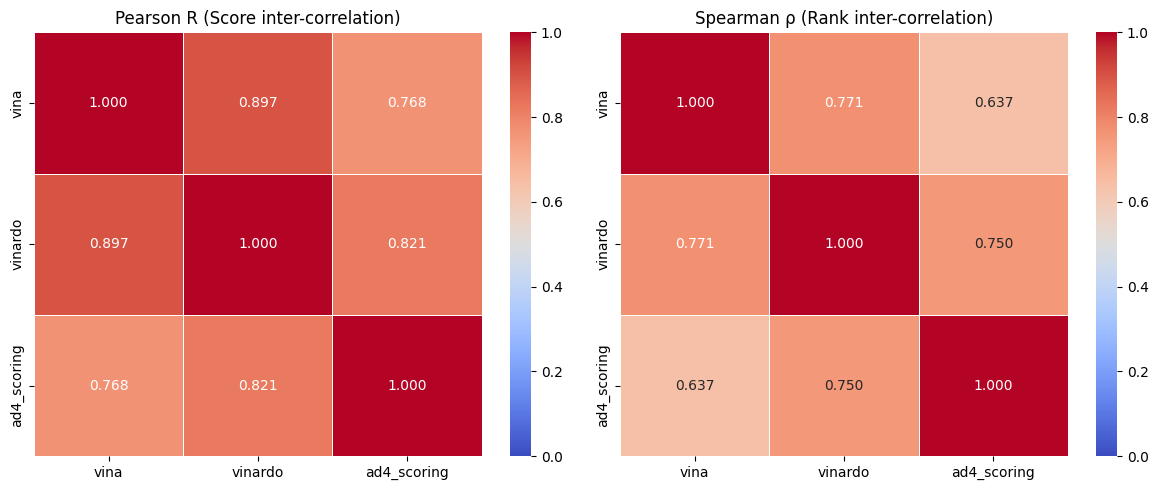

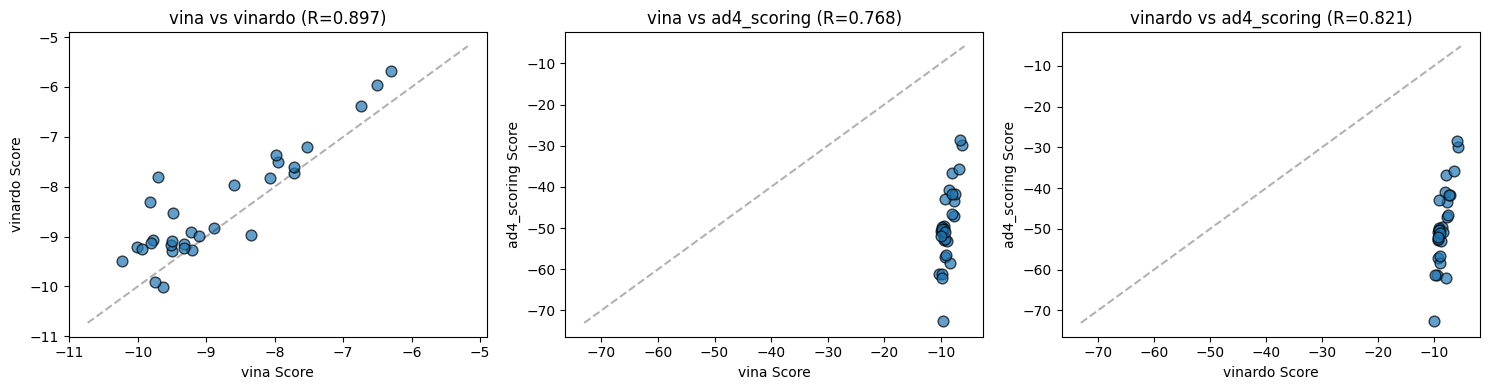

높은 상관관계(R>0.9): SF간 순위가 비슷 → consensus 효과 제한적
낮은 상관관계(R<0.7): SF간 순위가 다름 → consensus가 효과적일 수 있음


In [10]:
#@title 4-3. Scoring Function 간 상관관계 {display-mode: "form"}
# 3가지 scoring function의 스코어가 서로 얼마나 일치하는지 확인
score_cols_best = [f'{sf}_best' for sf in SCORING_FUNCTIONS]
score_matrix = valid[score_cols_best].corr(method='pearson')
score_matrix_spearman = valid[score_cols_best].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(score_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0.5,
            linewidths=0.5, ax=axes[0], vmin=0, vmax=1,
            xticklabels=SCORING_FUNCTIONS, yticklabels=SCORING_FUNCTIONS)
axes[0].set_title('Pearson R (Score inter-correlation)')

sns.heatmap(score_matrix_spearman, annot=True, fmt='.3f', cmap='coolwarm', center=0.5,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1,
            xticklabels=SCORING_FUNCTIONS, yticklabels=SCORING_FUNCTIONS)
axes[1].set_title('Spearman ρ (Rank inter-correlation)')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'score_intercorrelation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Pairwise scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [(0,1), (0,2), (1,2)]
for idx, (a, b) in enumerate(pairs):
    sf_a, sf_b = SCORING_FUNCTIONS[a], SCORING_FUNCTIONS[b]
    col_a, col_b = f'{sf_a}_best', f'{sf_b}_best'
    r, _ = stats.pearsonr(valid[col_a], valid[col_b])
    axes[idx].scatter(valid[col_a], valid[col_b], s=60, alpha=0.7, edgecolors='black')
    axes[idx].set_xlabel(f'{sf_a} Score')
    axes[idx].set_ylabel(f'{sf_b} Score')
    axes[idx].set_title(f'{sf_a} vs {sf_b} (R={r:.3f})')
    # Diagonal
    lim = [min(valid[col_a].min(), valid[col_b].min())-0.5, max(valid[col_a].max(), valid[col_b].max())+0.5]
    axes[idx].plot(lim, lim, 'k--', alpha=0.3)
plt.tight_layout()
plt.show()

print('높은 상관관계(R>0.9): SF간 순위가 비슷 → consensus 효과 제한적')
print('낮은 상관관계(R<0.7): SF간 순위가 다름 → consensus가 효과적일 수 있음')


## 5. Consensus Scoring

여러 scoring function의 결과를 조합하면 예측력이 향상될 수 있습니다.

### 방법
1. **Average**: 모든 SF 스코어의 평균
2. **Rank-by-Rank**: 각 SF에서의 순위를 평균
3. **Linear Regression**: pIC50를 종속변수로, 각 SF 스코어를 독립변수로 선형 회귀


In [11]:
#@title 5-1. Consensus 스코어 계산 {display-mode: "form"}
valid = df.dropna(subset=[f'{sf}_best' for sf in SCORING_FUNCTIONS] + ['pIC50']).copy()

# 1. Average consensus
score_cols = [f'{sf}_best' for sf in SCORING_FUNCTIONS]
valid['consensus_avg'] = valid[score_cols].mean(axis=1)

# 2. Rank-by-rank consensus
for sf in SCORING_FUNCTIONS:
    valid[f'{sf}_rank'] = valid[f'{sf}_best'].rank()
rank_cols = [f'{sf}_rank' for sf in SCORING_FUNCTIONS]
valid['consensus_rank'] = valid[rank_cols].mean(axis=1)

# 3. Linear regression consensus
X = valid[score_cols].values
y = valid['pIC50'].values

lr = LinearRegression()
lr.fit(X, y)
valid['consensus_lr'] = lr.predict(X)

# Correlations
consensus_methods = {
    'Average Score': 'consensus_avg',
    'Rank-by-Rank': 'consensus_rank',
    'Linear Regression': 'consensus_lr',
}

consensus_results = []
for method_name, col in consensus_methods.items():
    r, p = stats.pearsonr(valid[col], valid['pIC50'])
    rho, sp = stats.spearmanr(valid[col], valid['pIC50'])
    consensus_results.append({
        'Method': method_name,
        'Pearson R': round(r, 3),
        'Spearman ρ': round(rho, 3),
        'R²': round(r**2, 3),
    })

# Add individual SFs for comparison
for sf in SCORING_FUNCTIONS:
    r, _ = stats.pearsonr(valid[f'{sf}_best'], valid['pIC50'])
    rho, _ = stats.spearmanr(valid[f'{sf}_best'], valid['pIC50'])
    consensus_results.append({
        'Method': f'{sf} (single)',
        'Pearson R': round(r, 3),
        'Spearman ρ': round(rho, 3),
        'R²': round(r**2, 3),
    })

cons_df = pd.DataFrame(consensus_results).sort_values('R²', ascending=False)
print('=== Single vs Consensus Scoring ===')
cons_df


=== Single vs Consensus Scoring ===


,Method,Pearson R,Spearman ρ,R²
2,Linear Regression,0.359,0.324,0.129
4,vinardo (single),-0.259,-0.255,0.067
3,vina (single),-0.254,-0.162,0.064
1,Rank-by-Rank,-0.150,-0.165,0.022
0,Average Score,-0.116,-0.039,0.013
5,ad4_scoring (single),-0.078,-0.013,0.006


### Consensus Scoring 시각화

3가지 consensus 방법의 예측력을 산점도로 비교합니다.
R²가 높을수록 예측이 정확합니다.


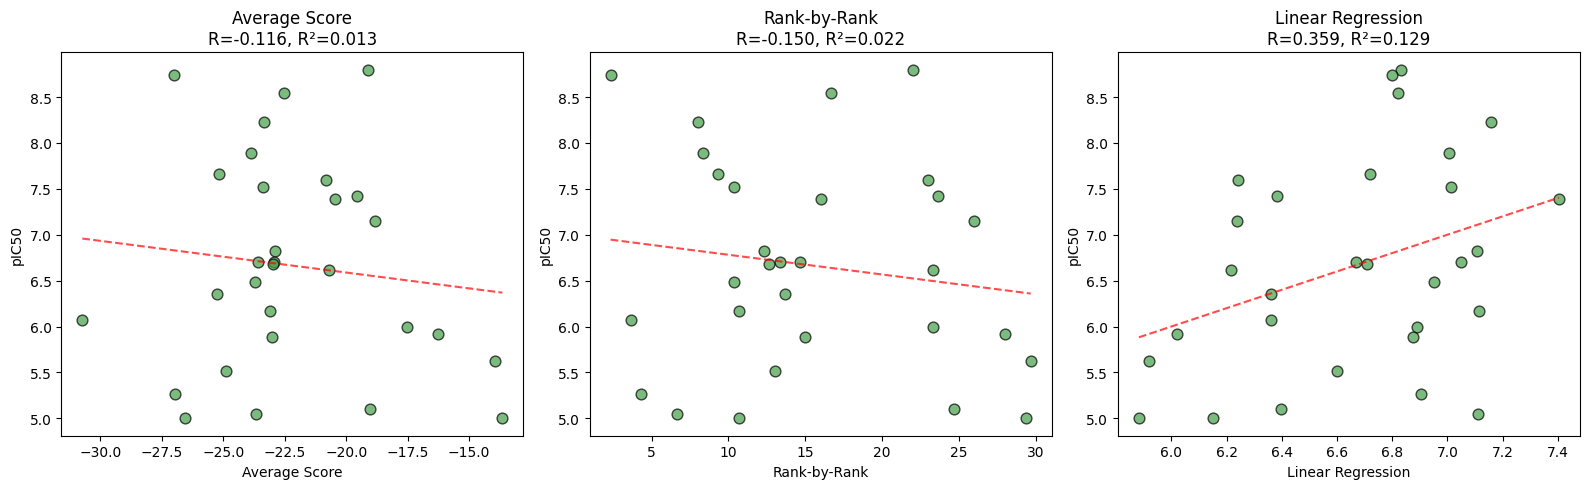

In [12]:
#@title 5-2. Consensus Scoring 시각화 {display-mode: "form"}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (method_name, col) in enumerate(consensus_methods.items()):
    r, _ = stats.pearsonr(valid[col], valid['pIC50'])

    axes[idx].scatter(valid[col], valid['pIC50'], s=60, alpha=0.7, c='#43A047', edgecolors='black')

    # Trend line
    z = np.polyfit(valid[col].values, valid['pIC50'].values, 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
    axes[idx].plot(x_line, p(x_line), 'r--', alpha=0.7)

    axes[idx].set_xlabel(method_name)
    axes[idx].set_ylabel('pIC50')
    axes[idx].set_title(f'{method_name}\nR={r:.3f}, R²={r**2:.3f}')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'consensus_scoring.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. 최적 예측 모델

### Random Forest
비선형 관계도 포착할 수 있는 Random Forest 모델을 사용하여
도킹 스코어 + 분자 속성으로 pIC50를 예측합니다.


=== Model Comparison (Leave-One-Out CV) ===
Random Forest:     R=0.101, RMSE=1.21
Linear Regression: R=0.446, RMSE=1.04


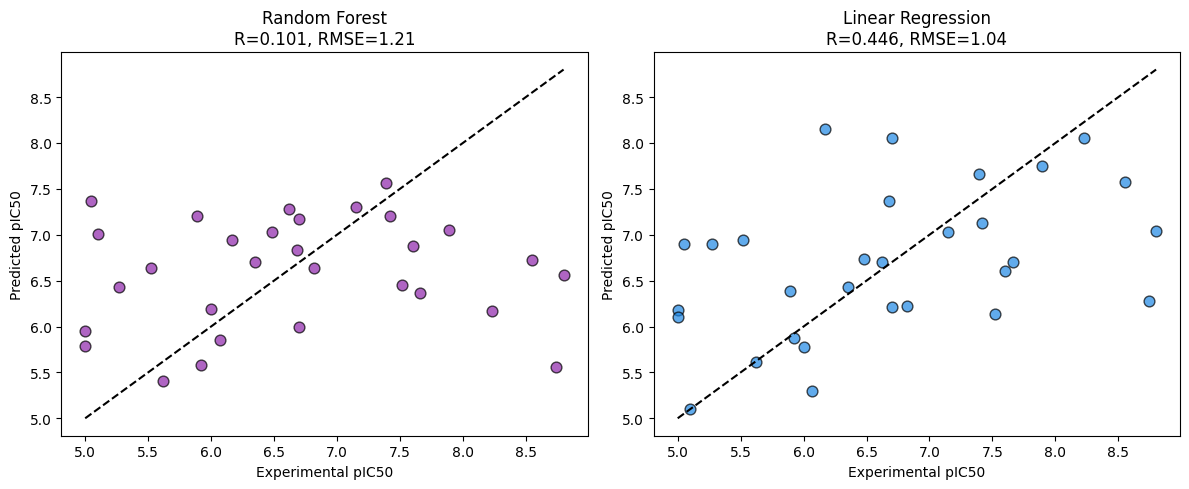

In [13]:
#@title 6-1. Random Forest 모델 {display-mode: "form"}
# Features: all scoring function scores + molecular descriptors
feature_cols = score_cols + ['MW', 'HA']
X_all = valid[feature_cols].values
y_all = valid['pIC50'].values

# Leave-one-out cross-validation (small dataset)
from sklearn.model_selection import LeaveOneOut, cross_val_predict

loo = LeaveOneOut()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
y_pred_rf = cross_val_predict(rf, X_all, y_all, cv=loo)

r_rf, _ = stats.pearsonr(y_pred_rf, y_all)
rho_rf, _ = stats.spearmanr(y_pred_rf, y_all)
rmse_rf = np.sqrt(mean_squared_error(y_all, y_pred_rf))

# Compare with simple Linear Regression LOO
lr2 = LinearRegression()
y_pred_lr = cross_val_predict(lr2, X_all, y_all, cv=loo)
r_lr, _ = stats.pearsonr(y_pred_lr, y_all)
rmse_lr = np.sqrt(mean_squared_error(y_all, y_pred_lr))

print('=== Model Comparison (Leave-One-Out CV) ===')
print(f'Random Forest:     R={r_rf:.3f}, RMSE={rmse_rf:.2f}')
print(f'Linear Regression: R={r_lr:.3f}, RMSE={rmse_lr:.2f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_all, y_pred_rf, s=60, alpha=0.7, c='#8E24AA', edgecolors='black')
axes[0].plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], 'k--')
axes[0].set_xlabel('Experimental pIC50')
axes[0].set_ylabel('Predicted pIC50')
axes[0].set_title(f'Random Forest\nR={r_rf:.3f}, RMSE={rmse_rf:.2f}')

axes[1].scatter(y_all, y_pred_lr, s=60, alpha=0.7, c='#1E88E5', edgecolors='black')
axes[1].plot([y_all.min(), y_all.max()], [y_all.min(), y_all.max()], 'k--')
axes[1].set_xlabel('Experimental pIC50')
axes[1].set_ylabel('Predicted pIC50')
axes[1].set_title(f'Linear Regression\nR={r_lr:.3f}, RMSE={rmse_lr:.2f}')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


### Feature Importance

Random Forest가 pIC50 예측에 어떤 feature를 가장 중요하게 사용하는지 확인합니다.
어떤 scoring function이 가장 예측력이 높은지 알 수 있습니다.


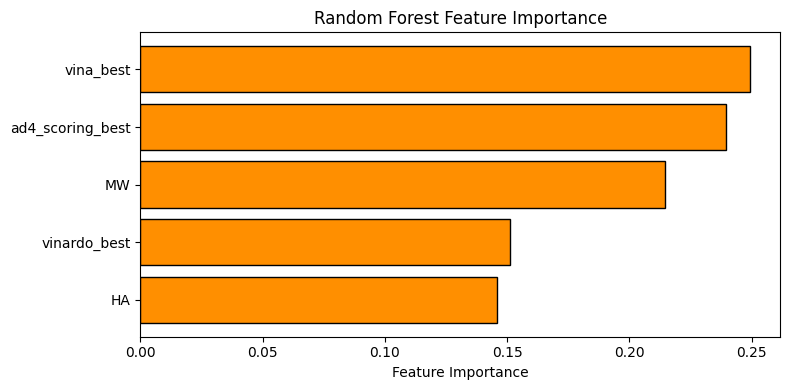

=== Feature Importance ===


,Feature,Importance
0,vina_best,0.249111
2,ad4_scoring_best,0.239316
3,MW,0.214628
1,vinardo_best,0.151056
4,HA,0.145889


In [14]:
#@title 6-2. Feature Importance (Random Forest) {display-mode: "form"}
# Fit on full data for feature importance
rf_full = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full.fit(X_all, y_all)

importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance['Feature'], importance['Importance'], color='#FF8F00', edgecolor='black')
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('=== Feature Importance ===')
importance


## 7. 종합 결과 & 내보내기


In [15]:
#@title 7-1. 최종 비교 테이블 {display-mode: "form"}
# Combine all results
final = cons_df.copy()
final = pd.concat([final, pd.DataFrame([
    {'Method': 'Random Forest (LOO-CV)', 'Pearson R': round(r_rf, 3), 'Spearman ρ': round(rho_rf, 3), 'R²': round(r_rf**2, 3)},
    {'Method': 'Linear Reg (LOO-CV)', 'Pearson R': round(r_lr, 3), 'Spearman ρ': round(stats.spearmanr(y_pred_lr, y_all)[0], 3), 'R²': round(r_lr**2, 3)},
])]).sort_values('R²', ascending=False).reset_index(drop=True)

best_method = final.iloc[0]['Method']
best_r2 = final.iloc[0]['R²']

print(f'=== Best Model: {best_method} (R²={best_r2}) ===')
final


=== Best Model: Linear Reg (LOO-CV) (R²=0.199) ===


,Method,Pearson R,Spearman ρ,R²
0,Linear Reg (LOO-CV),0.446,0.462,0.199
1,Linear Regression,0.359,0.324,0.129
2,vinardo (single),-0.259,-0.255,0.067
3,vina (single),-0.254,-0.162,0.064
4,Rank-by-Rank,-0.150,-0.165,0.022
5,Average Score,-0.116,-0.039,0.013
6,Random Forest (LOO-CV),0.101,0.108,0.010
7,ad4_scoring (single),-0.078,-0.013,0.006


### 결과 내보내기

전체 스코어 테이블(CSV)과 모델 비교 결과를 저장합니다.


In [16]:
#@title 7-2. 결과 내보내기 {display-mode: "form"}
import shutil

# Save full results
valid.to_csv(os.path.join(WORK_DIR, 'scoring_validation.csv'), index=False)
final.to_csv(os.path.join(WORK_DIR, 'model_comparison.csv'), index=False)
print('CSV saved.')

# Zip
zip_path = os.path.join(os.path.dirname(WORK_DIR), 'scoring_validation')

# 단백질 PDB + 도킹 포즈를 뷰어용 폴더에 복사
import glob as _glob
results_dir = os.path.join(WORK_DIR, 'results_for_viewer')
os.makedirs(results_dir, exist_ok=True)
shutil.copy2(prot_H, os.path.join(results_dir, os.path.basename(prot_H)))
for _sdf in _glob.glob(os.path.join(WORK_DIR, '*_docked.sdf')):
    shutil.copy2(_sdf, results_dir)
print(f'뷰어용 파일: {results_dir}/')
print('  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기')

shutil.make_archive(zip_path, 'zip', WORK_DIR)
print(f'Archive: {zip_path}.zip')
try:
    from google.colab import files
    files.download(f'{zip_path}.zip')
except ImportError:
    print(f'Results at: {WORK_DIR}')


CSV saved.
뷰어용 파일: /content/scoring_validation/results_for_viewer/
  PyMOL/ChimeraX: protein.pdb + *_docked.sdf 를 함께 열기
Archive: /content/scoring_validation.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 최적 모델로 새 화합물 스코어링

검증된 최적 모델을 사용하여 새 화합물의 활성을 예측합니다.
smina로 도킹 → 3가지 SF 스코어 수집 → 학습된 모델로 pIC50 예측.


In [17]:
#@title 8-1. 새 화합물 SMILES 입력 {display-mode: "form"}

NEW_SMILES = [
    {"name": "Query_1", "smiles": "c1ccc2c(c1)c1ccccc1[nH]2"},
    {"name": "Query_2", "smiles": "c1ccc(-c2ccncc2)cc1"},
    {"name": "Query_3", "smiles": "CC(=O)Nc1ccc(O)cc1"},
]

# 또는 직접 입력:
# NEW_SMILES = [{"name": "my_cpd", "smiles": "여기에_SMILES"}]

print(f'{len(NEW_SMILES)} new compounds to score')
for cpd in NEW_SMILES:
    print(f'  {cpd["name"]}: {cpd["smiles"][:50]}')


3 new compounds to score
  Query_1: c1ccc2c(c1)c1ccccc1[nH]2
  Query_2: c1ccc(-c2ccncc2)cc1
  Query_3: CC(=O)Nc1ccc(O)cc1


### 도킹 + 모델 예측

새 화합물을 3가지 SF로 도킹하고, 학습된 모델로 pIC50를 예측합니다.


In [18]:
#@title 8-2. 도킹 + 예측 pIC50 {display-mode: "form"}
new_results = []

for cpd in NEW_SMILES:
    name = cpd['name']
    smi = cpd['smiles']
    print(f'{name}...', flush=True)

    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        print(f'  Invalid SMILES')
        continue

    # Direct openbabel SMILES→3D SDF (avoids atom count mismatch from RDKit roundtrip)
    lig_sdf = os.path.join(WORK_DIR, f'new_{name}.sdf')
    try:
        ob_mol = pybel.readstring('smi', smi)
        ob_mol.addh()
        ob_mol.make3D(forcefield='mmff94', steps=100)
        lout = pybel.Outputfile(filename=lig_sdf, format='sdf', overwrite=True)
        lout.write(ob_mol); lout.close()
    except Exception as e:
        print(f'  openbabel 3D failed ({e}), using RDKit fallback')
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        AllChem.MMFFOptimizeMolecule(mol)
        writer = Chem.SDWriter(lig_sdf)
        writer.write(mol)
        writer.close()

    row = {'Name': name, 'SMILES': smi,
           'MW': round(Descriptors.MolWt(Chem.RemoveHs(mol)), 1),
           'HA': Chem.RemoveHs(mol).GetNumHeavyAtoms()}

    # Dock with all scoring functions
    for sf in SCORING_FUNCTIONS:
        sdf_out = os.path.join(WORK_DIR, f'new_{name}_{sf}.sdf')
        cmd = f'{smina} -r {rec_qt} -l {lig_sdf} -o {sdf_out} --scoring {sf} --center_x {center["x"]} --center_y {center["y"]} --center_z {center["z"]} --size_x {size["x"]} --size_y {size["y"]} --size_z {size["z"]} --exhaustiveness {EXHAUSTIVENESS} --num_modes {N_POSES} --cpu {N_CPUS} 2>/dev/null'
        os.system(cmd)

        scores = []
        if os.path.exists(sdf_out) and os.path.getsize(sdf_out) > 0:
            suppl = list(Chem.SDMolSupplier(sdf_out, removeHs=False))
            for pose_mol in suppl:
                if pose_mol is None: continue
                p = pose_mol.GetPropsAsDict()
                if 'minimizedAffinity' in p:
                    try: scores.append(float(p['minimizedAffinity']))
                    except: pass
        row[f'{sf}_best'] = min(scores) if scores else None

    new_results.append(row)

new_df = pd.DataFrame(new_results)

# Predict pIC50 using trained models
feature_cols_pred = [f'{sf}_best' for sf in SCORING_FUNCTIONS] + ['MW', 'HA']
X_new = new_df[feature_cols_pred].values

# Linear Regression prediction
new_df['pred_pIC50_LR'] = lr.predict(new_df[[f'{sf}_best' for sf in SCORING_FUNCTIONS]].values)

# Random Forest prediction (retrained on full data)
rf_full.fit(X_all, y_all)
new_df['pred_pIC50_RF'] = rf_full.predict(X_new)

# Estimated IC50
new_df['est_IC50_nM_LR'] = [round(10**(9 - pic50), 1) for pic50 in new_df['pred_pIC50_LR']]
new_df['est_IC50_nM_RF'] = [round(10**(9 - pic50), 1) for pic50 in new_df['pred_pIC50_RF']]

print('\n=== Prediction Results ===')
display_cols = ['Name'] + [f'{sf}_best' for sf in SCORING_FUNCTIONS] + ['pred_pIC50_LR', 'pred_pIC50_RF', 'est_IC50_nM_RF']
new_df[display_cols]


Query_1...


[06:51:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:14] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

Query_2...


[06:51:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:22] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:29] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:29] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:29] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:29] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol

Query_3...


[06:51:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:46] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:51:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol


=== Prediction Results ===


[06:52:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:52:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:52:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:52:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[06:52:10] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


,Name,vina_best,vinardo_best,ad4_scoring_best,pred_pIC50_LR,pred_pIC50_RF,est_IC50_nM_RF
0,Query_1,-6.62791,-5.49861,-27.58023,6.008058,5.2773,5280.8
1,Query_2,-5.99795,-5.31751,-27.19207,5.828324,5.2933,5089.8
2,Query_3,-5.41503,-4.72954,-22.92108,5.666779,5.2933,5089.8


### 예측 결과 내보내기


In [19]:
#@title 8-3. 예측 결과 내보내기 {display-mode: "form"}
# Save predictions
pred_csv = os.path.join(WORK_DIR, 'new_compound_predictions.csv')
new_df.to_csv(pred_csv, index=False)
print(f'Predictions CSV: {pred_csv}')

# Save trained model coefficients
print(f'\nLinear Regression coefficients:')
for sf, coef in zip(SCORING_FUNCTIONS, lr.coef_):
    print(f'  {sf}: {coef:.4f}')
print(f'  intercept: {lr.intercept_:.4f}')
print(f'\n  Formula: pIC50 = {lr.intercept_:.2f}', end='')
for sf, coef in zip(SCORING_FUNCTIONS, lr.coef_):
    print(f' + {coef:.3f}×{sf}', end='')
print()

# smina command template for future use
print(f'\n=== smina 명령어 템플릿 ===')
print(f'각 scoring function으로 도킹 후, 위 공식에 대입하면 pIC50를 추정할 수 있습니다:')
for sf in SCORING_FUNCTIONS:
    print(f'  {smina} -r {rec_qt} -l YOUR_LIGAND.sdf -o out_{sf}.sdf --scoring {sf} --center_x {center["x"]:.1f} --center_y {center["y"]:.1f} --center_z {center["z"]:.1f} --size_x {size["x"]:.1f} --size_y {size["y"]:.1f} --size_z {size["z"]:.1f} --exhaustiveness 8')


Predictions CSV: /content/scoring_validation/new_compound_predictions.csv

Linear Regression coefficients:
  vina: -0.1840
  vinardo: -0.4613
  ad4_scoring: 0.0508
  intercept: 3.6529

  Formula: pIC50 = 3.65 + -0.184×vina + -0.461×vinardo + 0.051×ad4_scoring

=== smina 명령어 템플릿 ===
각 scoring function으로 도킹 후, 위 공식에 대입하면 pIC50를 추정할 수 있습니다:
  /content/bin/smina -r /content/scoring_validation/1m17_rec.pdbqt -l YOUR_LIGAND.sdf -o out_vina.sdf --scoring vina --center_x 21.7 --center_y 0.3 --center_z 52.1 --size_x 29.7 --size_y 18.7 --size_z 21.1 --exhaustiveness 8
  /content/bin/smina -r /content/scoring_validation/1m17_rec.pdbqt -l YOUR_LIGAND.sdf -o out_vinardo.sdf --scoring vinardo --center_x 21.7 --center_y 0.3 --center_z 52.1 --size_x 29.7 --size_y 18.7 --size_z 21.1 --exhaustiveness 8
  /content/bin/smina -r /content/scoring_validation/1m17_rec.pdbqt -l YOUR_LIGAND.sdf -o out_ad4_scoring.sdf --scoring ad4_scoring --center_x 21.7 --center_y 0.3 --center_z 52.1 --size_x 29.7 --size_y 18.

## 해석 가이드

### 상관관계 해석
| R² | 의미 |
|-----|------|
| > 0.7 | 우수 (도킹 스코어가 활성을 잘 예측) |
| 0.4 ~ 0.7 | 보통 (일부 예측력 있음) |
| < 0.4 | 약함 (스코어만으로 예측 어려움) |

### 일반적 경향
- 단일 scoring function의 R²는 보통 **0.1~0.4** 범위
- Consensus scoring은 단일 대비 **5~15% 향상** 가능
- Random Forest + 분자 속성 추가 시 추가 향상 가능

### 주의사항
- 도킹 스코어는 **상대적 순위(ranking)**에 더 적합
- 절대적 binding affinity 예측은 MD/FEP가 필요
- 30개 화합물은 통계적으로 적은 수 → 결과 해석에 주의
- Leave-one-out CV도 과적합 위험 있음 (특히 Random Forest)
